<a href="https://colab.research.google.com/github/iarabertopena/ml-learning-lab/blob/main/10_fold_cross_validation-ml_learning_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Bibliotecas

In [1]:
%%writefile requirements.txt
numpy
pandas
scipy
scikit-learn

matplotlib
seaborn
scikit-plot
autorank
tqdm
scikit-multilearn-ng

Writing requirements.txt


In [2]:
!pip install -r requirements.txt

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 5.9 MB/s eta 0:00:00
  Created wheel for baycomp: filename=baycomp-1.0.3-py3-none-any.whl size=18027 sha256=18a93f5d43b54363979130bcd2486c9d8a3de89c843511eb59d4f2d43eee4e3d
  Stored in directory: /root/.cache/pip/wheels/ff/39/6a/f87e05ad75b9d87f4eb262a897ec2fe3aab09449d13e3c3b2c
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=ffbdf81bd8dc13d7c17dc72389f352dae19c33018b9dae843906983a91f68913
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built baycomp liac-arff


### Imports

In [97]:
import numpy as np
import pandas as pd
import copy
import os

from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from skmultilearn.model_selection import IterativeStratification
from sklearn.model_selection import KFold
from sklearn.metrics import hamming_loss, f1_score, roc_auc_score, average_precision_score
from sklearn.ensemble import RandomForestClassifier
from skmultilearn.problem_transform import BinaryRelevance, LabelPowerset
from skmultilearn.ensemble import RakelD
from skmultilearn.adapt import MLkNN
from scipy.io import arff

from tqdm import tqdm

### Datasets

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/emotions.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/emotions")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_16191/3433904962.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/emotions")


In [5]:
import os
print(os.listdir("/content/emotions"))

['emotions']


In [6]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/VirusGO.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/VirusGO")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_16191/290855057.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/VirusGO")


In [7]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/VirusPseAAC.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/VirusPseAAC")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_16191/3928386207.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/VirusPseAAC")


In [8]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/GpositiveGO.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/GpositiveGO")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_16191/2743622664.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/GpositiveGO")


In [9]:
from google.colab import drive
drive.mount('/content/drive')

import tarfile

path = "/content/drive/MyDrive/IC_FAPESP/Datasets/Testes_básicos/GpositivePseAAC.tar.gz"

with tarfile.open(path, "r:gz") as tar:
    tar.extractall("/content/GpositivePseAAC")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_16191/2522697500.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall("/content/GpositivePseAAC")


In [10]:
datasets_paths = {
    "emotions": "/content/emotions/emotions/CrossValidation",
    "VirusGO": "/content/VirusGO/VirusGO/CrossValidation",
    "VirusPseAAC": "/content/VirusPseAAC/VirusPseAAC/CrossValidation",
    "GpositiveGO": "/content/GpositiveGO/GpositiveGO/CrossValidation",
    "GpositivePseAAC": "/content/GpositivePseAAC/GpositivePseAAC/CrossValidation"
}

n_labels_dict = {
    "emotions": 6,
    "VirusGO": 6,
    "VirusPseAAC": 6,
    "GpositiveGO": 4,
    "GpositivePseAAC": 4
}

### Métricas de avaliação

In [11]:
def evaluate_metrics(y_true, y_pred, y_prob):

    results = {}

    # binarizar (threshold 0.5)
    y_pred_bin = (y_prob >= 0.5).astype(int)

    results["hamming"] = hamming_loss(y_true, y_pred_bin)

    results["f1_micro"] = f1_score(y_true, y_pred_bin, average='micro')
    results["f1_macro"] = f1_score(y_true, y_pred_bin, average='macro')

    try:
      results["auprc_micro"] = average_precision_score(y_true, y_prob, average='micro')
      #results["auprc_macro"] = average_precision_score(y_true, y_prob, average='macro')
    except Exception as e :
      y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
      results["auprc_micro"] = average_precision_score(y_true, y_prob, average='micro')
      #results["auprc_micro"] = np.nan
      #results["auprc_macro"] = np.nan

    try:
      results["auc_micro"] = roc_auc_score(y_true, y_prob, average='micro')
      #results["auc_macro"] = roc_auc_score(y_true, y_prob, average='macro')
    except:
      results["auc_micro"] = np.nan
      #results["auc_macro"] = np.nan

    return results

In [12]:
# Hamming Loss:
# Proporção de labels incorretamente previstas (falsos positivos + falsos negativos).
# Quanto menor, melhor.

# F1-score (micro):
# Agrega contribuições de todas as classes.
# Favorece classes mais frequentes.

# F1-score (macro):
# Calcula F1 por classe e tira média.
# Dá o mesmo peso para classes raras e frequentes.


# AUPRC (Área sob a curva Precision-Recall):
# Mais informativa que AUC quando há desbalanceamento.
# Mede qualidade das probabilidades previstas.
    # Micro: avalia globalmente (classes frequentes têm mais peso)
    # Macro: média entre classes (importante para labels raros)

# AUC:
# Mede a capacidade do modelo de separar classes positivas e negativas.
    # Micro: mais influenciado por classes frequentes
    # Macro: trata todas as classes igualmente

### Definindo os modelos

In [13]:
# Definindo os modelos:
def get_models():
    return {
        "BR": BinaryRelevance(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "LP": LabelPowerset(
            classifier=RandomForestClassifier(n_estimators=100, random_state=42)
        ),

        "RAkEL": RakelD(
            base_classifier=RandomForestClassifier(n_estimators=100, random_state=42),
            labelset_size=2
        ),

        "RF": RandomForestClassifier(n_estimators=100, random_state=42),

        "MLkNN": MLkNN(k=10)
    }

In [14]:
# BR (Binary Relevance):
# Decompõe o problema multi-label em vários classificadores binários independentes.
# Simples e eficiente, mas ignora correlação entre labels.

# LP (Label Powerset):
# Transforma o problema multi-label em multi-classe usando combinações de labels.
# Captura dependências, mas pode gerar muitas classes distintas.

# RAkEL:
# Usa vários modelos LP em subconjuntos aleatórios de labels.
# Reduz a complexidade do LP e mantém parte das dependências.

# MLkNN:
# Extensão do kNN para multi-label baseada em probabilidade.
# Considera vizinhos mais próximos e estima a probabilidade de cada label.
# Consegue capturar dependência local entre labels.

# Random Forest (adaptado para multi-label):
# Conjunto de árvores de decisão usado como classificador base.
# Robusto a ruído e capaz de modelar relações não lineares.
# Quando usado com BR ou LP, herda suas características.

### Experimento inicial

#### Loop principal + cross validation

In [116]:
def run_experiment_folds_default(models, base_path, n_labels):

    path_tr = os.path.join(base_path, "Tr")
    path_vl = os.path.join(base_path, "Vl")
    path_ts = os.path.join(base_path, "Ts")

    def sort_key(filename):
        return int(filename.split("-")[-1].split(".")[0])

    arquivos_tr = sorted([f for f in os.listdir(path_tr) if f.endswith(".arff")], key=sort_key)
    arquivos_vl = sorted([f for f in os.listdir(path_vl) if f.endswith(".arff")], key=sort_key)
    arquivos_ts = sorted([f for f in os.listdir(path_ts) if f.endswith(".arff")], key=sort_key)

    results_default = {name: [] for name in models.keys()}

    for tr_file, vl_file, ts_file in zip(arquivos_tr, arquivos_vl, arquivos_ts):

        print("Rodando fold:", tr_file)

        # carregar
        tr = load_data(os.path.join(path_tr, tr_file))
        vl = load_data(os.path.join(path_vl, vl_file))
        ts = load_data(os.path.join(path_ts, ts_file))

        # concatenação
        train_full = pd.concat([tr, vl], axis=0)

        # separar X e Y (ajustar n_labels!)
        X_train = train_full.iloc[:, :-n_labels]
        Y_train = train_full.iloc[:, -n_labels:]

        X_test = ts.iloc[:, :-n_labels]
        Y_test = ts.iloc[:, -n_labels:]

        # rodar modelos
        for name in models:
            model = copy.deepcopy(models[name])

            model.fit(X_train.values, Y_train.values)
            Y_pred = model.predict(X_test.values)

            y_prob = None
            if hasattr(model, "predict_proba"):
              try:
                y_prob = model.predict_proba(X_test.values)

                if isinstance(y_prob, list):
                  y_prob = np.array([p[:, 1] for p in y_prob]).T

              except:
                y_prob = None

            #res = evaluate_metrics(Y_test.values, Y_pred, None)
            res = evaluate_metrics(Y_test.values, Y_pred, y_prob)
            results_default[name].append(res)

    return results_default

In [117]:
def load_data(path):
    if path.endswith(".arff"):
        data, meta = arff.loadarff(path)
        df = pd.DataFrame(data)

        # converter de bytes para string
        for col in df.select_dtypes([object]).columns:
            df[col] = df[col].str.decode("utf-8")

        # converter tudo para numérico
        df = df.apply(pd.to_numeric)

        return df

    elif path.endswith(".csv"):
        return pd.read_csv(path)

    else:
        raise ValueError(f"Formato não suportado: {path}")

In [118]:
# teste com 1 dataset
dataset_name = "emotions"

base_path = datasets_paths[dataset_name]
n_labels = n_labels_dict[dataset_name]

In [119]:
results_default = run_experiment_folds_default(get_models(), base_path, n_labels)

Rodando fold: emotions-Split-Tr-1.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-2.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-3.arff


...

/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-9.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-10.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


#### Resumindo os resultados iniciais

In [122]:
# Resumindo os resultados:
def summarize_results_default(results_default):
    summary_default = {}

    for model, res_list in results_default.items():

        if len(res_list) == 0:
            print(f"{model} sem resultados, ignorando... :/")
            continue

        summary_default[model] = {}

        for metric in res_list[0].keys():
            values = [
                r[metric]
                for r in res_list
                if r[metric] is not None and not np.isnan(r[metric])
            ]

            if len(values) > 0:
                summary_default[model][metric] = (
                    np.mean(values),
                    np.std(values)
                )
            else:
                summary_default[model][metric] = (np.nan, np.nan)

    return summary_default

In [123]:
summary_default = summarize_results_default(results_default)

for model, metrics in summary_default.items():
    print(f"\n--- {model} ---")
    for k, (mean, std) in metrics.items():
        if np.isnan(mean):
            print(f"{k}: nan")
        else:
            print(f"{k}: {mean:.4f} ± {std:.4f}")


--- BR ---
hamming: 0.1800 ± 0.0164
f1_micro: 0.6869 ± 0.0256
f1_macro: 0.6571 ± 0.0300
auprc_micro: 0.7655 ± 0.0385
auc_micro: 0.8787 ± 0.0206

--- LP ---
hamming: 0.1854 ± 0.0167
f1_micro: 0.6688 ± 0.0322
f1_macro: 0.6288 ± 0.0292
auprc_micro: 0.7565 ± 0.0433
auc_micro: 0.8758 ± 0.0209

--- RAkEL ---
hamming: 0.1754 ± 0.0196
f1_micro: 0.6879 ± 0.0364
f1_macro: 0.6549 ± 0.0387
auprc_micro: 0.7607 ± 0.0411
auc_micro: 0.8760 ± 0.0213

--- RF ---
hamming: 0.1840 ± 0.0209
f1_micro: 0.6766 ± 0.0355
f1_macro: 0.6410 ± 0.0376
auprc_micro: 0.7562 ± 0.0367
auc_micro: 0.8748 ± 0.0199

--- MLkNN ---
hamming: 0.2582 ± 0.0154
f1_micro: 0.5149 ± 0.0363
f1_macro: 0.4551 ± 0.0384
auprc_micro: 0.5850 ± 0.0238
auc_micro: 0.7607 ± 0.0250


#### Rodando os 5 datasets

In [124]:
results_default_all = {}

for name, base_path in datasets_paths.items():
    print(f"\n====================")
    print(f"Dataset: {name}")
    print(f"====================")

    n_labels = n_labels_dict[name]

    results = run_experiment_folds_default(get_models(), base_path, n_labels)

    summary_default = summarize_results_default(results)

    results_default_all[name] = summary_default


Dataset: emotions
Rodando fold: emotions-Split-Tr-1.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-2.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-3.arff


...

/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: GpositivePseAAC-Split-Tr-9.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: GpositivePseAAC-Split-Tr-10.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


In [127]:
for dataset, summary_default in results_default_all.items():
    print(f"\n====================")
    print(f"Dataset: {dataset}")
    print(f"====================")

    for model, metrics in summary_default.items():
        print(f"\n--- {model} ---")
        for metric, (mean, std) in metrics.items():
            if np.isnan(mean):
                print(f"{metric}: nan")
            else:
                print(f"{metric}: {mean:.4f} ± {std:.4f}")


Dataset: emotions

--- BR ---
hamming: 0.1800 ± 0.0164
f1_micro: 0.6869 ± 0.0256
f1_macro: 0.6571 ± 0.0300
auprc_micro: 0.7655 ± 0.0385
auc_micro: 0.8787 ± 0.0206

--- LP ---
hamming: 0.1854 ± 0.0167
f1_micro: 0.6688 ± 0.0322
f1_macro: 0.6288 ± 0.0292
auprc_micro: 0.7565 ± 0.0433
auc_micro: 0.8758 ± 0.0209

--- RAkEL ---
hamming: 0.1801 ± 0.0151
f1_micro: 0.6805 ± 0.0277
f1_macro: 0.6416 ± 0.0332
auprc_micro: 0.7578 ± 0.0382
auc_micro: 0.8752 ± 0.0196

--- RF ---
hamming: 0.1840 ± 0.0209
f1_micro: 0.6766 ± 0.0355
f1_macro: 0.6410 ± 0.0376
auprc_micro: 0.7562 ± 0.0367
auc_micro: 0.8748 ± 0.0199

--- MLkNN ---
hamming: 0.2582 ± 0.0154
f1_micro: 0.5149 ± 0.0363
f1_macro: 0.4551 ± 0.0384
auprc_micro: 0.5850 ± 0.0238
auc_micro: 0.7607 ± 0.0250

Dataset: VirusGO

--- BR ---
hamming: 0.0533 ± 0.0263
f1_micro: 0.8641 ± 0.0656
f1_macro: 0.8160 ± 0.0970
auprc_micro: 0.9223 ± 0.0523
auc_micro: 0.9805 ± 0.0164

--- LP ---
hamming: 0.0550 ± 0.0245
f1_micro: 0.8584 ± 0.0609
f1_macro: 0.8139 ± 0.083

#### Tabelas de resultados

In [128]:
def build_table(results_default_all, metric_name):
    rows = []

    for dataset_name, models in all_results.items():
        row = {"dataset": dataset_name}

        for model_name, metrics in models.items():
            mean, std = metrics[metric_name]
            row[model_name] = mean

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("dataset")

    return df

In [130]:
metrics = [
    "hamming",
    "f1_micro",
    "f1_macro",
    "auprc_micro",
    #"auprc_macro",
    "auc_micro",
    #"auc_macro"
]

for metric in metrics:
    print(f"\n===== {metric.upper()} =====")

    df = build_table(results_default_all, metric)

    print(df.to_string())


===== HAMMING =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.179966  0.185392  0.180603  0.183976  0.258201
VirusGO          0.053333  0.054960  0.051706  0.054921  0.079048
VirusPseAAC      0.173095  0.173016  0.184444  0.179603  0.191111
GpositiveGO      0.031336  0.029894  0.029894  0.030855  0.030311
GpositivePseAAC  0.144562  0.149379  0.149332  0.148454  0.144986

===== F1_MICRO =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.686909  0.668780  0.681383  0.676610  0.514890
VirusGO          0.864111  0.858351  0.868339  0.858521  0.797980
VirusPseAAC      0.427957  0.389879  0.351631  0.353153  0.469776
GpositiveGO      0.937221  0.939607  0.939779  0.937839  0.938295
GpositivePseAAC  0.642621  0.628353  0.626557  0.629896  0.679966

===== F1_MACRO =====
           

#### Testes estatísticos

##### Hamming Loss


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.142473  0.158602  0.137097  0.137097  0.244624
1  0.192529  0.204023  0.186782  0.204023  0.258621
2  0.169355  0.185484  0.182796  0.174731  0.233871
3  0.183333  0.166667  0.163889  0.166667  0.269444
4  0.174863  0.183060  0.191257  0.185792  0.273224
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR         2.10  0.179966  0.017238      NaN      NaN         0.0  negligible   
RAkEL      2.15  0.179516  0.018108      NaN      NaN    0.025461  negligible   
LP         2.85  0.185392  0.017564      NaN      NaN   -0.311838       small   
RF         2.90  0.183976  0.022064      NaN      NaN    -0.20254       small   
MLkNN      5.00  0.258201  0.016248      NaN      NaN   -4.670715       large   

      effect_size_above magnitude_above  
BR                  0.0      negligible  
RAkEL          0.025461      negligible  
LP            -0.329446    

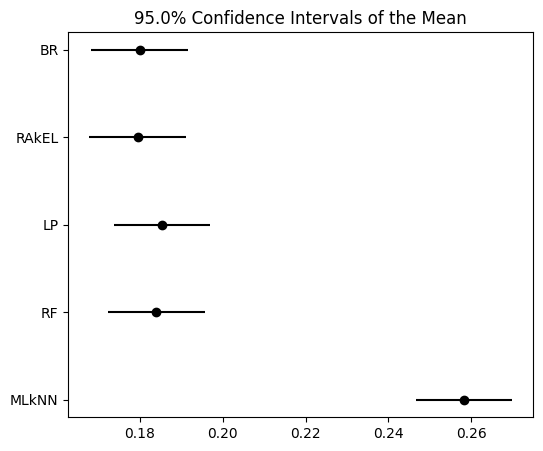


Wilcoxon: RAkEL vs BR
p-valor: 0.845703125

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.041667  0.041667  0.033333  0.033333  0.058333
1  0.031746  0.023810  0.023810  0.023810  0.071429
2  0.047619  0.047619  0.047619  0.047619  0.023810
3  0.079365  0.079365  0.079365  0.087302  0.071429
4  0.116667  0.108333  0.108333  0.108333  0.108333
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
RAkEL      2.25  0.050913  0.028262      NaN      NaN         0.0  negligible   
BR         2.90  0.053333  0.027700      NaN      NaN   -0.086505  negligible   
LP         2.95  0.054960  0.025833      NaN      NaN   -0.149497  negligible   
RF         2.95  0.054921  0.027381      NaN      NaN   -0.144041  negligible   
MLkNN      3.95  0.079048  0.024970      NaN      NaN   -1.055043       large   

      effect_size_above magnitude_above  
RAkEL               0.0      negligible  
BR            -0.086505   

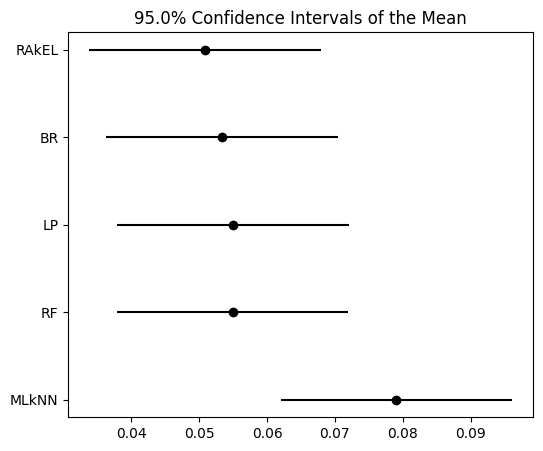


Wilcoxon: RAkEL vs BR
p-valor: 0.5

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.141667  0.158333  0.158333  0.166667  0.191667
1  0.166667  0.174603  0.198413  0.150794  0.214286
2  0.190476  0.190476  0.174603  0.214286  0.214286
3  0.158730  0.190476  0.166667  0.174603  0.134921
4  0.200000  0.208333  0.216667  0.216667  0.233333
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR         2.30  0.173095  0.017166      NaN      NaN         0.0  negligible   
LP         2.55  0.173016  0.022433      NaN      NaN    0.003973  negligible   
RAkEL      2.80  0.177937  0.022406      NaN      NaN   -0.242565       small   
RF         3.35  0.179603  0.023232      NaN      NaN   -0.318615       small   
MLkNN      4.00  0.191111  0.033378      NaN      NaN   -0.678823      medium   

      effect_size_above magnitude_above  
BR                  0.0      negligible  
LP             0.003973      n

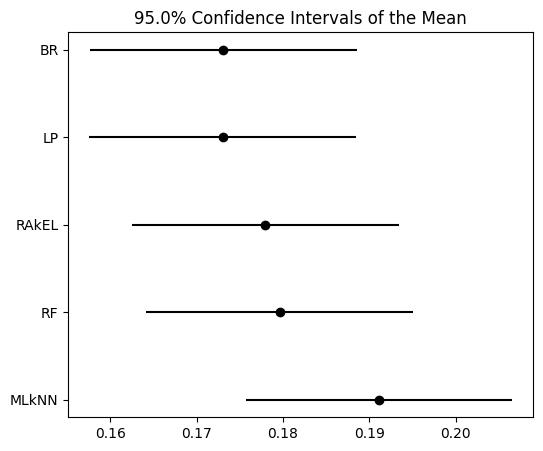


Wilcoxon: LP vs BR
p-valor: 0.8046875

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.019608  0.019608  0.034314  0.019608  0.014706
1  0.014151  0.014151  0.014151  0.014151  0.042453
2  0.028846  0.033654  0.024038  0.033654  0.033654
3  0.028846  0.028846  0.028846  0.028846  0.028846
4  0.019231  0.019231  0.024038  0.014423  0.014423
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
MLkNN      2.55  0.030311  0.010057      NaN      NaN         0.0  negligible   
LP         2.90  0.029894  0.009644      NaN      NaN    0.042315  negligible   
RF         3.10  0.030855  0.011660      NaN      NaN   -0.050019  negligible   
RAkEL      3.15  0.031845  0.009800      NaN      NaN   -0.154532  negligible   
BR         3.30  0.031336  0.011667      NaN      NaN    -0.09414  negligible   

      effect_size_above magnitude_above  
MLkNN               0.0      negligible  
LP             0.042315    

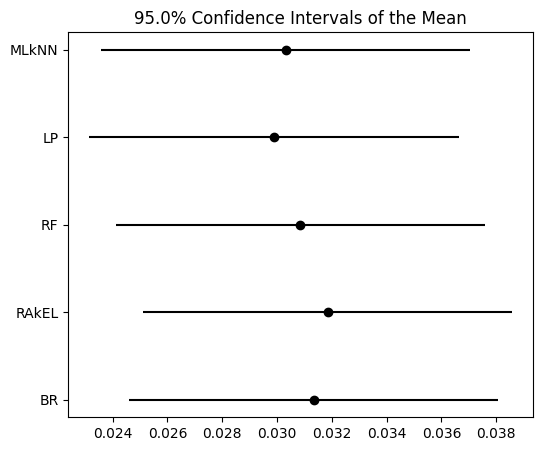


Wilcoxon: LP vs MLkNN
p-valor: 0.625

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.137255  0.137255  0.117647  0.137255  0.093137
1  0.141509  0.136792  0.132075  0.127358  0.136792
2  0.115385  0.144231  0.115385  0.153846  0.125000
3  0.153846  0.144231  0.149038  0.153846  0.173077
4  0.125000  0.139423  0.139423  0.139423  0.139423
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
RAkEL       2.3  0.141639  0.027934      NaN      NaN         0.0  negligible   
BR          3.0  0.144562  0.028817      NaN      NaN      -0.103  negligible   
RF          3.2  0.148454  0.027858      NaN      NaN   -0.244308       small   
MLkNN       3.2  0.144986  0.033099      NaN      NaN   -0.109285  negligible   
LP          3.3  0.149379  0.023716      NaN      NaN   -0.298706       small   

      effect_size_above magnitude_above  
RAkEL               0.0      negligible  
BR               -0.103 

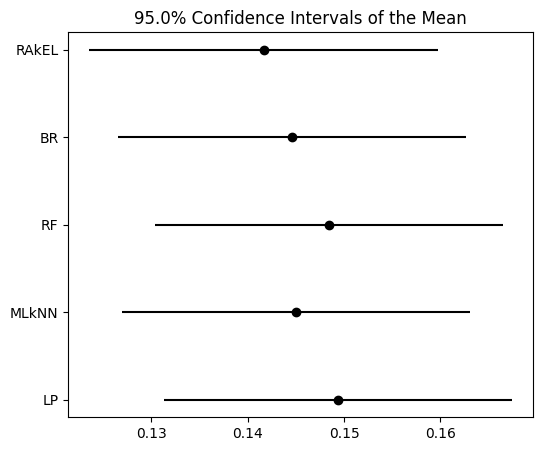


Wilcoxon: RAkEL vs BR
p-valor: 0.40625


In [181]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_default_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_default_all[dataset], "hamming")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='ascending', verbose=False)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=True)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

##### F1-score


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.743961  0.712195  0.745098  0.753623  0.551724
1  0.663317  0.628272  0.645833  0.632124  0.526316
2  0.686567  0.663265  0.669951  0.682927  0.575610
3  0.688679  0.716981  0.698565  0.714286  0.507614
4  0.680000  0.659898  0.646154  0.682927  0.484536
Fail to reject null hypothesis that data is normal for column BR (p=0.429709>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.801147>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.902996>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.503447>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.930402>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.878361>=0.050000)
Rejecting null hypothesis that there is no

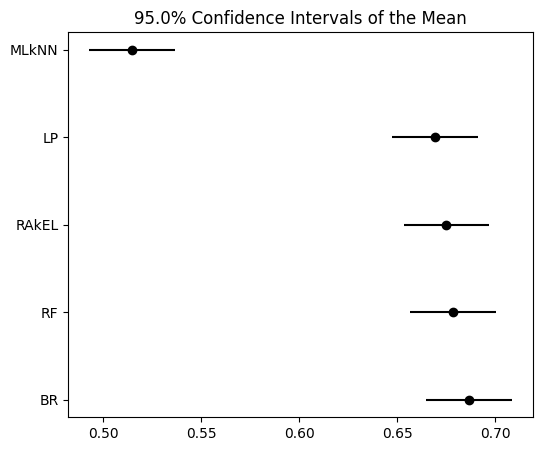


Wilcoxon: BR vs RF
p-valor: 0.16015625

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.869565  0.869565  0.913043  0.869565  0.851064
1  0.920000  0.938776  0.901961  0.938776  0.800000
2  0.880000  0.875000  0.875000  0.893617  0.936170
3  0.816327  0.791667  0.791667  0.765957  0.800000
4  0.708333  0.734694  0.734694  0.734694  0.745098
Fail to reject null hypothesis that data is normal for column BR (p=0.020534>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.731699>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.147232>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.447578>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.022481>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.988607>=0.050000)
Rej

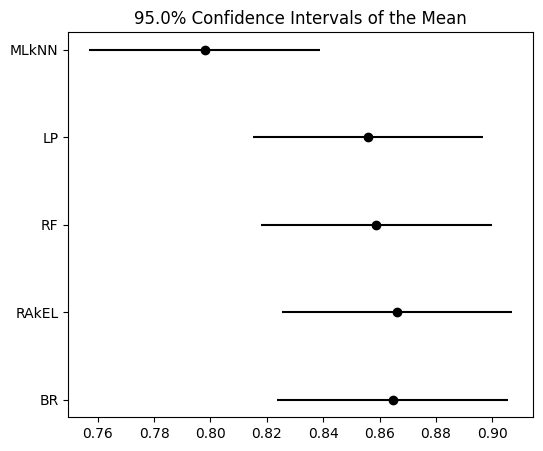


Wilcoxon: RAkEL vs BR
p-valor: 0.84375

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.514286  0.387097  0.424242  0.444444  0.410256
1  0.400000  0.450000  0.388889  0.421053  0.425532
2  0.400000  0.333333  0.368421  0.228571  0.425532
3  0.411765  0.352941  0.294118  0.352941  0.585366
4  0.333333  0.285714  0.294118  0.187500  0.391304
Fail to reject null hypothesis that data is normal for column BR (p=0.447118>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.930380>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.663275>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.821524>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.026908>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.654972>=0.050000)

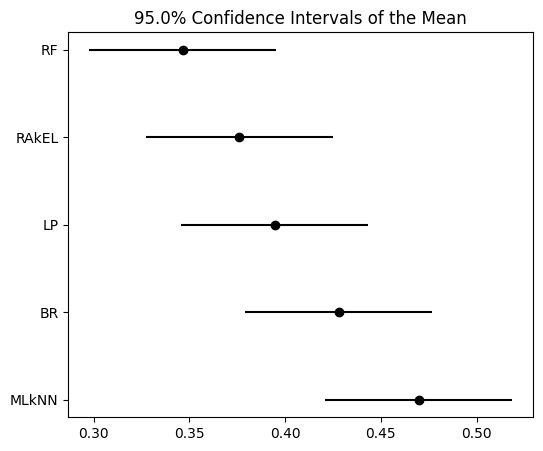


Wilcoxon: MLkNN vs BR
p-valor: 0.23828125

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.960000  0.960000  0.960000  0.960000  0.970297
1  0.971429  0.971429  0.971429  0.941176  0.912621
2  0.951456  0.932039  0.951456  0.932039  0.932039
3  0.942308  0.942308  0.942308  0.942308  0.941176
4  0.961538  0.961538  0.951456  0.970874  0.970874
Fail to reject null hypothesis that data is normal for column BR (p=0.580276>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.335865>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.141077>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.256424>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.243210>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.901989>=0.0500

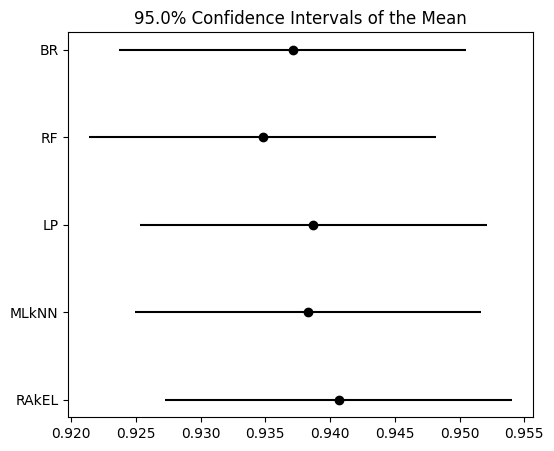


Wilcoxon: RAkEL vs LP
p-valor: 0.625

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.641026  0.650000  0.714286  0.658537  0.800000
1  0.651163  0.658824  0.674419  0.689655  0.694737
2  0.720930  0.642857  0.689655  0.619048  0.723404
3  0.600000  0.626506  0.585366  0.609756  0.600000
4  0.704545  0.666667  0.658824  0.650602  0.694737
Fail to reject null hypothesis that data is normal for column BR (p=0.338674>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.317043>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.837196>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.860006>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.674574>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.960445>=0.05000

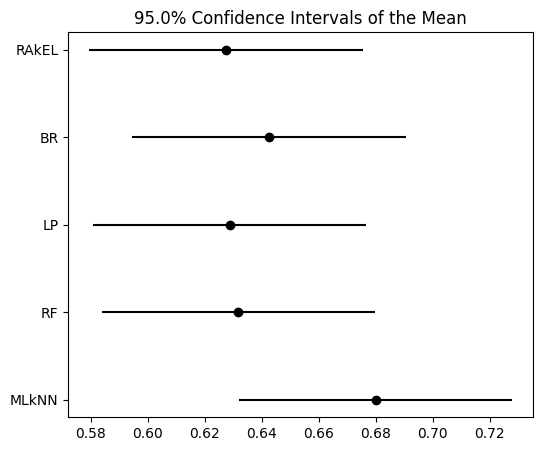


Wilcoxon: MLkNN vs BR
p-valor: 0.02734375


In [177]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_default_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_default_all[dataset], "f1_micro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.735422  0.689061  0.730133  0.731058  0.495545
1  0.643397  0.590733  0.639841  0.591360  0.430123
2  0.662186  0.625548  0.638572  0.649348  0.532061
3  0.632622  0.660177  0.673333  0.666968  0.445507
4  0.675035  0.641015  0.637262  0.654326  0.434215
Fail to reject null hypothesis that data is normal for column BR (p=0.021762>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.532474>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.077953>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.246800>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.866125>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.893625>=0.050000)
Rejecting null hypothesis that there is no

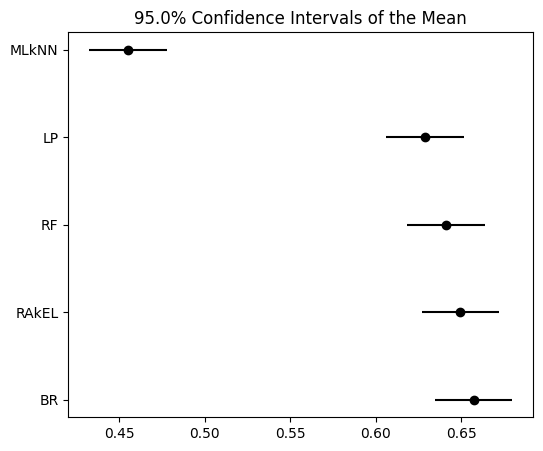


Wilcoxon: BR vs RAkEL
p-valor: 0.431640625

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.702614  0.747141  0.702614  0.702614  0.736111
1  0.902116  0.910831  0.879085  0.925926  0.641433
2  0.708325  0.708325  0.707407  0.660566  0.712418
3  0.853571  0.853571  0.853571  0.837088  0.701389
4  0.627646  0.657407  0.657407  0.638367  0.629630
Fail to reject null hypothesis that data is normal for column BR (p=0.087851>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.523518>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.308623>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.250734>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.628790>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.900425>=0.050000)

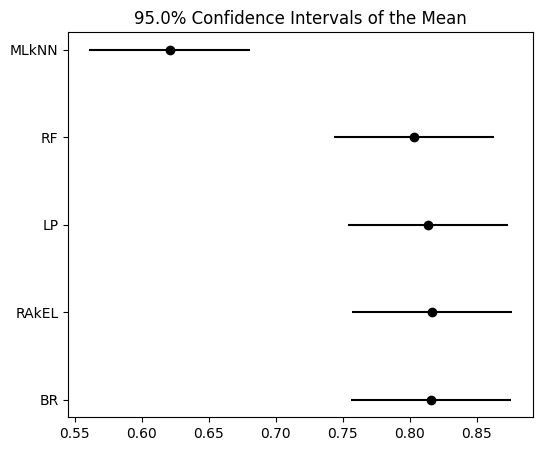


Wilcoxon: RAkEL vs BR
p-valor: 0.9375

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.214286  0.163170  0.179487  0.184127  0.238828
1  0.316162  0.331933  0.300000  0.354701  0.453922
2  0.151282  0.138095  0.177778  0.092308  0.163889
3  0.326923  0.275641  0.316162  0.297009  0.396825
4  0.294872  0.273504  0.252914  0.227273  0.325815
Fail to reject null hypothesis that data is normal for column BR (p=0.096256>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.074587>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.247334>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.565385>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.762414>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.827774>=0.050000)


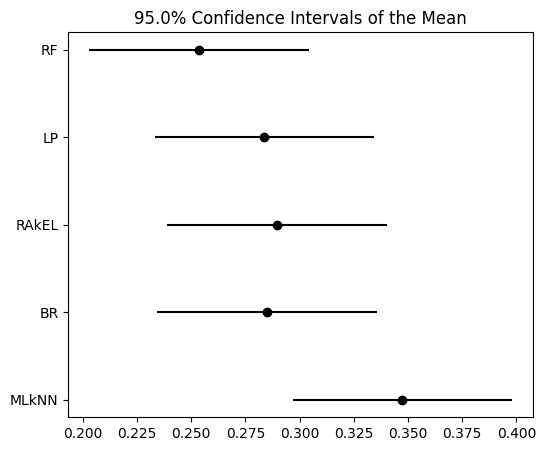


Wilcoxon: MLkNN vs RAkEL
p-valor: 0.013671875

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.722024  0.722024  0.706447  0.722024  0.976447
1  0.976760  0.976760  0.976760  0.976760  0.914683
2  0.871961  0.860294  0.879091  0.860294  0.809816
3  0.877793  0.877793  0.877793  0.877793  0.880293
4  0.973011  0.973011  0.964443  0.978561  0.971591
Fail to reject null hypothesis that data is normal for column BR (p=0.010810>=0.010000)
Rejecting null hypothesis that data is normal for column LP (p=0.007173<0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.057435>=0.010000)
Rejecting null hypothesis that data is normal for column RF (p=0.008109<0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.258087>=0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.992839>=0.050000)
Using Friedman 

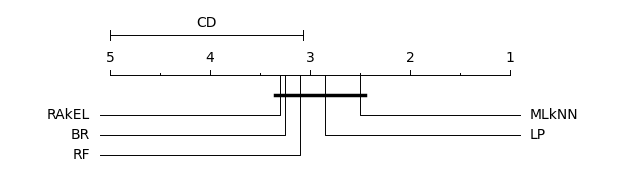


Wilcoxon: MLkNN vs RAkEL
p-valor: 0.322265625

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.438140  0.443011  0.477193  0.445929  0.603503
1  0.408929  0.408929  0.440179  0.467752  0.679352
2  0.529202  0.453620  0.533376  0.421474  0.550879
3  0.416038  0.446674  0.445911  0.418670  0.441217
4  0.507860  0.471232  0.463553  0.464672  0.661449
Fail to reject null hypothesis that data is normal for column BR (p=0.537072>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.380135>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.617136>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.323488>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.235720>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.419417

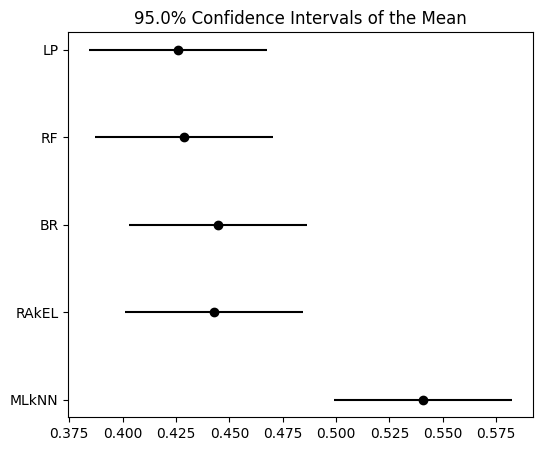


Wilcoxon: MLkNN vs BR
p-valor: 0.001953125


In [182]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_default_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_default_all[dataset], "f1_macro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

##### AUPRC


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.830075  0.813552  0.847630  0.810132  0.593266
1  0.755209  0.744682  0.776556  0.754680  0.616451
2  0.765655  0.756608  0.773104  0.761314  0.600115
3  0.766269  0.804508  0.764422  0.778213  0.548954
4  0.798918  0.776184  0.785625  0.772132  0.562883
Fail to reject null hypothesis that data is normal for column BR (p=0.809229>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.151672>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.204284>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.246784>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.397567>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.541312>=0.050000)
Rejecting null hypothesis that there is no

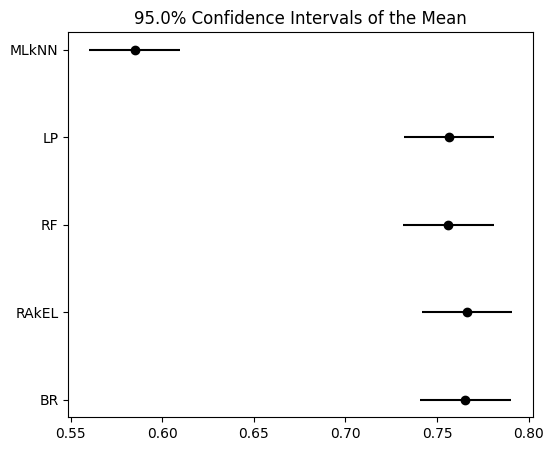


Wilcoxon: RAkEL vs BR
p-valor: 0.76953125

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.948250  0.935423  0.957909  0.955249  0.913647
1  0.927438  0.945849  0.969297  0.953604  0.865992
2  0.954837  0.954145  0.953448  0.952942  0.949649
3  0.873636  0.881793  0.869151  0.886977  0.937091
4  0.791919  0.803120  0.809353  0.798241  0.732663
Fail to reject null hypothesis that data is normal for column BR (p=0.074017>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.017998>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.024059>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.019553>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.072433>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.988824>=0.050000)


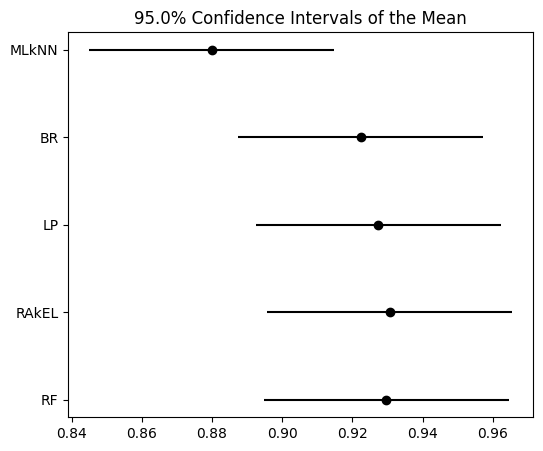


Wilcoxon: RAkEL vs RF
p-valor: 0.921875

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.620333  0.588144  0.615773  0.571607  0.540644
1  0.540220  0.548292  0.522146  0.586093  0.420510
2  0.509781  0.544167  0.574117  0.521688  0.437313
3  0.606515  0.570834  0.603847  0.583550  0.601911
4  0.548742  0.527822  0.514445  0.561442  0.522131
Fail to reject null hypothesis that data is normal for column BR (p=0.553619>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.025082>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.813537>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.081380>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.945284>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.967316>=0.050000

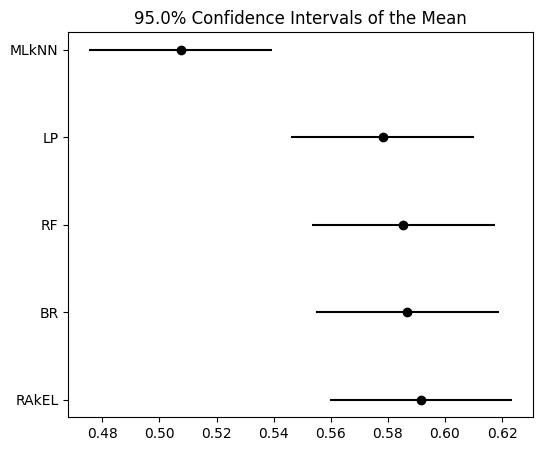


Wilcoxon: RAkEL vs BR
p-valor: 0.921875

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.976089  0.977804  0.975463  0.976616  0.983894
1  0.998595  0.998192  0.998595  0.997806  0.987244
2  0.988647  0.987631  0.988591  0.987588  0.973174
3  0.956975  0.964973  0.966562  0.967996  0.962118
4  0.997822  0.997486  0.995803  0.997848  0.989379
Fail to reject null hypothesis that data is normal for column BR (p=0.525938>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.374499>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.785468>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.561824>=0.010000)
Rejecting null hypothesis that data is normal for column MLkNN (p=0.006926<0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.733617>=0.050000)
Using Friedman 

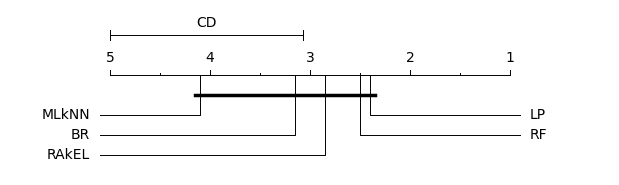


Wilcoxon: LP vs RF
p-valor: 0.322265625

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.877275  0.861837  0.878162  0.860832  0.879926
1  0.764158  0.807714  0.778330  0.765678  0.814395
2  0.840586  0.814948  0.827244  0.800737  0.790424
3  0.756848  0.806281  0.784767  0.755891  0.700219
4  0.779906  0.773408  0.783470  0.801773  0.741395
Fail to reject null hypothesis that data is normal for column BR (p=0.505875>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.327796>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.389675>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.539439>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.852295>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.996688>=0.05

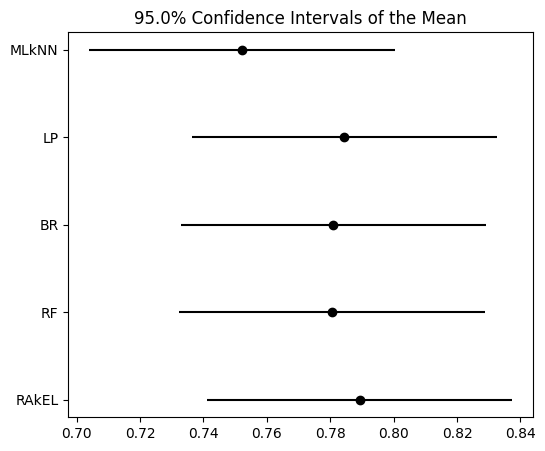


Wilcoxon: RAkEL vs LP
p-valor: 0.322265625


In [184]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_default_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_default_all[dataset], "auprc_micro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

##### AUC


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.916468  0.910186  0.922267  0.914949  0.794829
1  0.870073  0.869614  0.873835  0.871008  0.791673
2  0.873356  0.868664  0.875990  0.868839  0.769317
3  0.895836  0.908255  0.894491  0.899073  0.763582
4  0.888920  0.878924  0.877947  0.876438  0.719762
Fail to reject null hypothesis that data is normal for column BR (p=0.736289>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.393605>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.738237>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.793641>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.374944>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.961736>=0.050000)
Rejecting null hypothesis that there is no

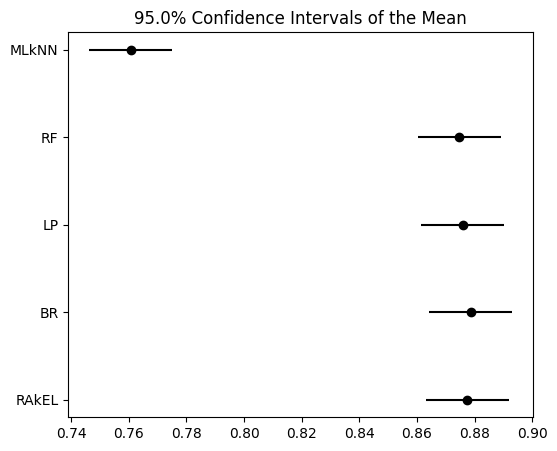


Wilcoxon: BR vs RAkEL
p-valor: 1.0

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.986111  0.980035  0.988715  0.987630  0.965495
1  0.989583  0.990605  0.993873  0.992034  0.979575
2  0.987525  0.986931  0.987525  0.987723  0.964554
3  0.971287  0.975050  0.972079  0.973861  0.985347
4  0.935086  0.920350  0.937276  0.923536  0.914576
Rejecting null hypothesis that data is normal for column BR (p=0.001316<0.010000)
Rejecting null hypothesis that data is normal for column LP (p=0.000104<0.010000)
Rejecting null hypothesis that data is normal for column RAkEL (p=0.000812<0.010000)
Rejecting null hypothesis that data is normal for column RF (p=0.000349<0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.044882>=0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.988990>=0.050000)
Using Friedman test as omnibus test
Reject

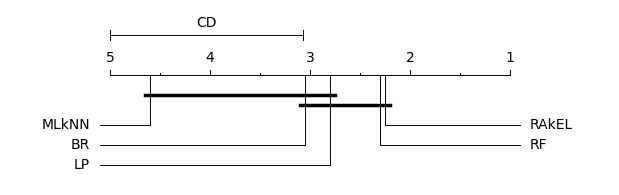


Wilcoxon: RAkEL vs RF
p-valor: 0.76953125

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.849392  0.815972  0.844401  0.854167  0.797743
1  0.821895  0.841299  0.829248  0.846814  0.800245
2  0.807327  0.839406  0.820396  0.840792  0.814455
3  0.848713  0.831485  0.866931  0.848515  0.864950
4  0.823178  0.821585  0.823775  0.831740  0.791318
Fail to reject null hypothesis that data is normal for column BR (p=0.333332>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.603702>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.912591>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.839886>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.575182>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.545074>=0.0500

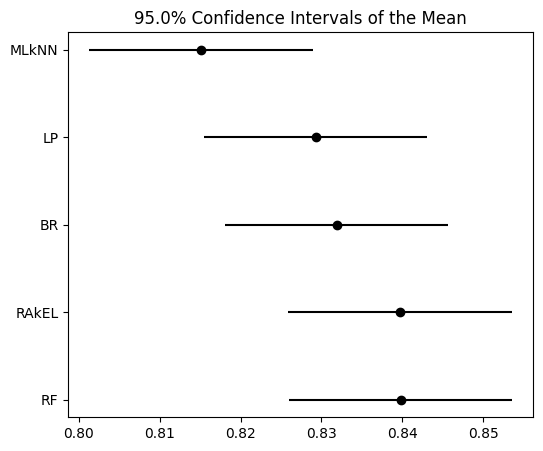


Wilcoxon: RF vs RAkEL
p-valor: 1.0

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.981289  0.982955  0.981610  0.981866  0.989363
1  0.999525  0.999407  0.999525  0.999288  0.996143
2  0.994887  0.994400  0.994887  0.994522  0.981923
3  0.988104  0.987919  0.989707  0.988967  0.985639
4  0.999260  0.999260  0.998582  0.999322  0.995069
Fail to reject null hypothesis that data is normal for column BR (p=0.714757>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.442253>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.558878>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.491249>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.039926>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.139109>=0.050000)
Rej

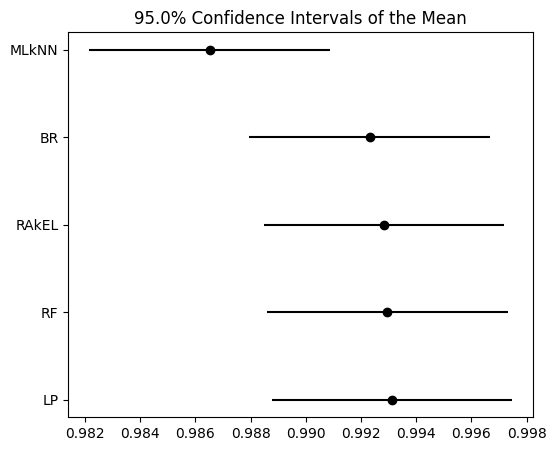


Wilcoxon: LP vs RF
p-valor: 0.193359375

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.940023  0.929707  0.948417  0.935538  0.946495
1  0.892251  0.910348  0.903821  0.891183  0.918239
2  0.907486  0.903956  0.907486  0.899087  0.910286
3  0.874260  0.907483  0.886958  0.888622  0.874877
4  0.885417  0.901997  0.888930  0.905387  0.887266
Fail to reject null hypothesis that data is normal for column BR (p=0.306809>=0.010000)
Rejecting null hypothesis that data is normal for column LP (p=0.009487<0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.300117>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.206866>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.988863>=0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.984226>=0.050000)
Using Fried

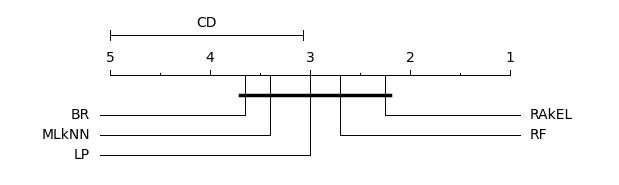


Wilcoxon: RAkEL vs RF
p-valor: 0.845703125


In [185]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_default_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_default_all[dataset], "auc_micro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

### Experimento com otimização de parâmetros

#### Loop principal + otimização de parâmetros

In [188]:
def run_experiment_folds_tuned(models, base_path, n_labels):

    path_tr = os.path.join(base_path, "Tr")
    path_vl = os.path.join(base_path, "Vl")
    path_ts = os.path.join(base_path, "Ts")

    def sort_key(filename):
        return int(filename.split("-")[-1].split(".")[0])

    arquivos_tr = sorted([f for f in os.listdir(path_tr) if f.endswith(".arff")], key=sort_key)
    arquivos_vl = sorted([f for f in os.listdir(path_vl) if f.endswith(".arff")], key=sort_key)
    arquivos_ts = sorted([f for f in os.listdir(path_ts) if f.endswith(".arff")], key=sort_key)

    results_tuned = {name: [] for name in models.keys()}

    # grade de parâmetros
    param_grid = {
    "BR": [
        {"classifier__n_estimators": 50},
        {"classifier__n_estimators": 100}
    ],
    "LP": [
        {"classifier__n_estimators": 50},
        {"classifier__n_estimators": 100}
    ],
    "RF": [
        {"n_estimators": 50},
        {"n_estimators": 100}
    ],
    "RAkEL": [
        {"labelset_size": 3},
        {"labelset_size": 5}
    ],
    "MLkNN": [
        {"k": 5},
        {"k": 10}
    ]
}

    for tr_file, vl_file, ts_file in zip(arquivos_tr, arquivos_vl, arquivos_ts):

        print("Rodando fold:", tr_file)

        # carregar dados
        tr = load_data(os.path.join(path_tr, tr_file))
        vl = load_data(os.path.join(path_vl, vl_file))
        ts = load_data(os.path.join(path_ts, ts_file))

        # separar treino e validação
        X_train = tr.iloc[:, :-n_labels]
        Y_train = tr.iloc[:, -n_labels:]

        X_val = vl.iloc[:, :-n_labels]
        Y_val = vl.iloc[:, -n_labels:]

        X_test = ts.iloc[:, :-n_labels]
        Y_test = ts.iloc[:, -n_labels:]

        for name in models:

            best_score = -np.inf
            best_model = None

            grid = param_grid.get(name, [{}])

            # loop de parâmetros
            for param in grid:

                model = copy.deepcopy(models[name])

                if param != {}:
                  try:
                    model.set_params(**param)
                  except:
                    pass

                model.fit(X_train.values, Y_train.values)

                # previsão validação
                y_prob = None
                if hasattr(model, "predict_proba"):
                    try:
                        y_prob = model.predict_proba(X_val.values)

                        if hasattr(y_prob, "toarray"):
                          y_prob = y_prob.toarray()

                        elif isinstance(y_prob, list):
                          y_prob = np.array([p[:, 1] for p in y_prob]).T
                    except:
                        y_prob = None

                # só usa AUPRC se tiver probabilidade
                if y_prob is not None:
                    score = average_precision_score(Y_val.values, y_prob, average='micro')
                else:
                    score = 0  # fallback

                if score > best_score:
                    best_score = score
                    best_model = copy.deepcopy(model)

            # treino final (treino + validação)
            train_full = pd.concat([tr, vl], axis=0)

            X_train_full = train_full.iloc[:, :-n_labels]
            Y_train_full = train_full.iloc[:, -n_labels:]

            best_model.fit(X_train_full.values, Y_train_full.values)

            # teste
            Y_pred = best_model.predict(X_test.values)

            y_prob = None
            if hasattr(best_model, "predict_proba"):
                try:
                    y_prob = best_model.predict_proba(X_test.values)

                    if hasattr(y_prob, "toarray"):
                      y_prob = y_prob.toarray()

                    elif isinstance(y_prob, list):
                      y_prob = np.array([p[:, 1] for p in y_prob]).T
                except:
                    y_prob = None

            res = evaluate_metrics(Y_test.values, Y_pred, y_prob)
            results_tuned[name].append(res)

    return results_tuned

In [189]:
# teste com 1 dataset
dataset_name = "emotions"

base_path = datasets_paths[dataset_name]
n_labels = n_labels_dict[dataset_name]

In [190]:
results_tuned = run_experiment_folds_tuned(get_models(), base_path, n_labels)

Rodando fold: emotions-Split-Tr-1.arff
Rodando fold: emotions-Split-Tr-2.arff
Rodando fold: emotions-Split-Tr-3.arff
Rodando fold: emotions-Split-Tr-4.arff
Rodando fold: emotions-Split-Tr-5.arff
Rodando fold: emotions-Split-Tr-6.arff
Rodando fold: emotions-Split-Tr-7.arff
Rodando fold: emotions-Split-Tr-8.arff
Rodando fold: emotions-Split-Tr-9.arff
Rodando fold: emotions-Split-Tr-10.arff


#### Resumindo resultados iniciais

In [193]:
# Resumindo os resultados:
def summarize_results_tuned(results):
    summary_tuned = {}

    for model, res_list in results.items():

        if len(res_list) == 0:
            print(f"{model} sem resultados, ignorando... :/")
            continue

        summary_tuned[model] = {}

        for metric in res_list[0].keys():
            values = [
                r[metric]
                for r in res_list
                if r[metric] is not None and not np.isnan(r[metric])
            ]

            if len(values) > 0:
                summary_tuned[model][metric] = (
                    np.mean(values),
                    np.std(values)
                )
            else:
                summary_tuned[model][metric] = (np.nan, np.nan)

    return summary_tuned

In [194]:
summary_tuned = summarize_results_tuned(results)

for model, metrics in summary_tuned.items():
    print(f"\n--- {model} ---")
    for k, (mean, std) in metrics.items():
        if np.isnan(mean):
            print(f"{k}: nan")
        else:
            print(f"{k}: {mean:.4f} ± {std:.4f}")


--- BR ---
hamming: 0.1446 ± 0.0273
f1_micro: 0.6426 ± 0.0741
f1_macro: 0.4446 ± 0.0618
auprc_micro: 0.7810 ± 0.0764
auc_micro: 0.8878 ± 0.0392

--- LP ---
hamming: 0.1494 ± 0.0225
f1_micro: 0.6284 ± 0.0637
f1_macro: 0.4262 ± 0.0459
auprc_micro: 0.7845 ± 0.0694
auc_micro: 0.8941 ± 0.0368

--- RAkEL ---
hamming: 0.1517 ± 0.0282
f1_micro: 0.6191 ± 0.0739
f1_macro: 0.4211 ± 0.0598
auprc_micro: 0.7936 ± 0.0666
auc_micro: 0.8986 ± 0.0330

--- RF ---
hamming: 0.1485 ± 0.0264
f1_micro: 0.6299 ± 0.0714
f1_macro: 0.4289 ± 0.0504
auprc_micro: 0.7806 ± 0.0705
auc_micro: 0.8954 ± 0.0350

--- MLkNN ---
hamming: 0.1450 ± 0.0314
f1_micro: 0.6800 ± 0.0717
f1_macro: 0.5408 ± 0.0840
auprc_micro: 0.7522 ± 0.0746
auc_micro: 0.8837 ± 0.0364


#### Rodando os 5 datasets

In [195]:
results_default_all = {}
results_tuned_all = {}

for dataset in datasets_paths:

    print(f"\n====================")
    print(f"Dataset: {dataset}")
    print(f"====================")

    base_path = datasets_paths[dataset]
    n_labels = n_labels_dict[dataset]

    models = get_models()

    print("\n--- DEFAULT ---")
    results_default = run_experiment_folds_default(models, base_path, n_labels)

    models = get_models()

    print("\n--- TUNED ---")
    results_tuned = run_experiment_folds_tuned(models, base_path, n_labels)

    results_default_all[dataset] = results_default
    results_tuned_all[dataset] = results_tuned


Dataset: emotions

--- DEFAULT ---
Rodando fold: emotions-Split-Tr-1.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-2.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: emotions-Split-Tr-3.arff


...

Rodando fold: GpositivePseAAC-Split-Tr-9.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])


Rodando fold: GpositivePseAAC-Split-Tr-10.arff


/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])
/tmp/ipykernel_16191/1552914216.py:17: DeprecationWarning: `row_stack` alias is deprecated. Use `np.vstack` directly.
  y_prob = np.row_stack([m.toarray().ravel() for m in y_prob])



--- TUNED ---
Rodando fold: GpositivePseAAC-Split-Tr-1.arff
Rodando fold: GpositivePseAAC-Split-Tr-2.arff
Rodando fold: GpositivePseAAC-Split-Tr-3.arff
Rodando fold: GpositivePseAAC-Split-Tr-4.arff
Rodando fold: GpositivePseAAC-Split-Tr-5.arff
Rodando fold: GpositivePseAAC-Split-Tr-6.arff
Rodando fold: GpositivePseAAC-Split-Tr-7.arff
Rodando fold: GpositivePseAAC-Split-Tr-8.arff
Rodando fold: GpositivePseAAC-Split-Tr-9.arff
Rodando fold: GpositivePseAAC-Split-Tr-10.arff


In [196]:
def aggregate_results(results):

    aggregated = {}

    for model, folds in results.items():

        aggregated[model] = {}

        # normalizar formato
        if isinstance(folds, dict):
            first_value = list(folds.values())[0]

            if isinstance(first_value, dict):
                # dict de folds
                folds_list = list(folds.values())

                metrics = folds_list[0].keys()

                for metric in metrics:
                    values = [fold[metric] for fold in folds_list]
                    aggregated[model][metric] = (np.mean(values), np.std(values))

            else:
                # dict de métricas com lista
                for metric, values in folds.items():
                    aggregated[model][metric] = (np.mean(values), np.std(values))

        elif isinstance(folds, list):
            # lista de folds
            metrics = folds[0].keys()

            for metric in metrics:
                values = [fold[metric] for fold in folds]
                aggregated[model][metric] = (np.mean(values), np.std(values))

        else:
            raise ValueError(f"Formato inesperado em {model}")

    return aggregated

In [197]:
results_default_agg = {}

for dataset in results_default_all:
    results_default_agg[dataset] = aggregate_results(results_default_all[dataset])

In [198]:
results_tuned_agg = {}

for dataset in results_tuned_all:
    results_tuned_agg[dataset] = aggregate_results(results_tuned_all[dataset])

#### Tabelas de resultados

In [199]:
def build_table(all_results, metric_name):
    rows = []

    for dataset_name, models in all_results.items():
        row = {"dataset": dataset_name}

        for model_name, metrics in models.items():
            mean, std = metrics[metric_name]
            row[model_name] = mean

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("dataset")

    return df

In [200]:
metrics = [
    "hamming",
    "f1_micro",
    "f1_macro",
    "auprc_micro",
    #"auprc_macro",
    "auc_micro",
    #"auc_macro"
]

for metric in metrics:
    print(f"\n===== {metric.upper()} =====")

    df = build_table(results_tuned_agg, metric)

    print(df.to_string())


===== HAMMING =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.179966  0.184586  0.185451  0.183156  0.265818
VirusGO          0.053373  0.055794  0.054206  0.055000  0.066151
VirusPseAAC      0.173095  0.172222  0.175556  0.181984  0.187738
GpositiveGO      0.031336  0.030374  0.029894  0.032270  0.031781
GpositivePseAAC  0.144562  0.149859  0.149388  0.147964  0.147390

===== F1_MICRO =====
                       BR        LP     RAkEL        RF     MLkNN
dataset                                                          
emotions         0.686909  0.669435  0.669798  0.678566  0.510047
VirusGO          0.864672  0.855946  0.860270  0.858891  0.831572
VirusPseAAC      0.427957  0.394650  0.363930  0.346609  0.465725
GpositiveGO      0.937109  0.938695  0.939607  0.934814  0.935683
GpositivePseAAC  0.642621  0.628743  0.625038  0.631778  0.676613

===== F1_MACRO =====
           

#### Testes estatísticos

##### Hamming Loss


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.142473  0.158602  0.153226  0.137097  0.244624
1  0.192529  0.204023  0.181034  0.204023  0.258621
2  0.169355  0.177419  0.182796  0.174731  0.266129
3  0.183333  0.166667  0.161111  0.166667  0.269444
4  0.174863  0.183060  0.196721  0.177596  0.314208
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR         1.90  0.179966  0.017238      NaN      NaN         0.0  negligible   
LP         2.65  0.184586  0.017743      NaN      NaN   -0.264116       small   
RF         2.70  0.183156  0.022141      NaN      NaN    -0.16079  negligible   
RAkEL      2.75  0.185451  0.016631      NaN      NaN   -0.323859       small   
MLkNN      5.00  0.265818  0.021598      NaN      NaN    -4.39368       large   

      effect_size_above magnitude_above  
BR                  0.0      negligible  
LP            -0.264116           small  
RF             0.071262    

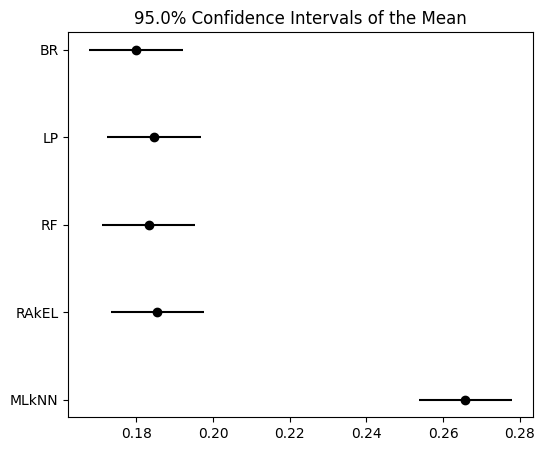


Wilcoxon: BR vs RF
p-valor: 0.205078125

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.050000  0.050000  0.050000  0.050000  0.058333
1  0.031746  0.023810  0.031746  0.023810  0.047619
2  0.047619  0.047619  0.039683  0.039683  0.023810
3  0.071429  0.079365  0.079365  0.087302  0.071429
4  0.116667  0.108333  0.116667  0.108333  0.108333
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR         2.75  0.053373  0.026730      NaN      NaN         0.0  negligible   
RF         2.75  0.055000  0.027719      NaN      NaN   -0.059752  negligible   
RAkEL      2.85  0.054206  0.027490      NaN      NaN   -0.030736  negligible   
LP         3.00  0.055794  0.025488      NaN      NaN   -0.092687  negligible   
MLkNN      3.65  0.066151  0.023161      NaN      NaN    -0.51093      medium   

      effect_size_above magnitude_above  
BR                  0.0      negligible  
RF            -0.059752      

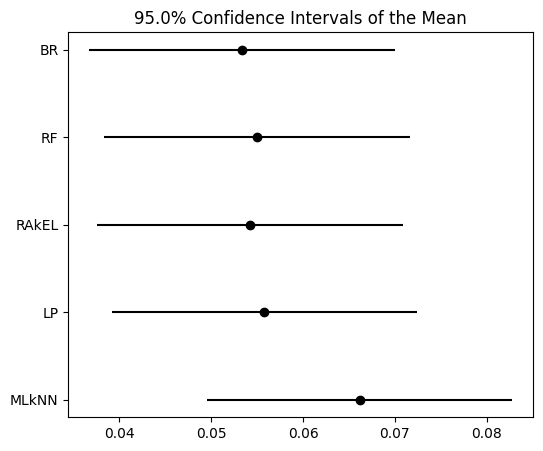


Wilcoxon: BR vs RAkEL
p-valor: 0.75

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.141667  0.158333  0.175000  0.166667  0.191667
1  0.166667  0.174603  0.158730  0.174603  0.198413
2  0.190476  0.190476  0.174603  0.214286  0.230159
3  0.158730  0.174603  0.190476  0.174603  0.134921
4  0.200000  0.208333  0.208333  0.216667  0.233333
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR         2.40  0.173095  0.017166      NaN      NaN         0.0  negligible   
LP         2.45  0.172222  0.021558      NaN      NaN    0.044802  negligible   
RAkEL      2.65  0.175556  0.016207      NaN      NaN   -0.147383  negligible   
RF         3.45  0.181984  0.021071      NaN      NaN   -0.462525       small   
MLkNN      4.05  0.187738  0.034187      NaN      NaN   -0.541327      medium   

      effect_size_above magnitude_above  
BR                  0.0      negligible  
LP             0.044802      

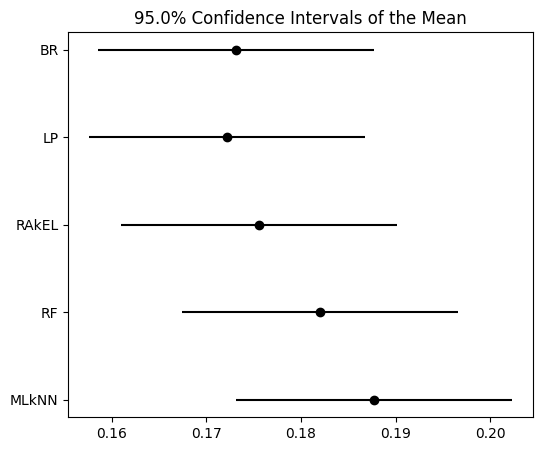


Wilcoxon: LP vs BR
p-valor: 0.78125

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.019608  0.019608  0.019608  0.019608  0.024510
1  0.014151  0.014151  0.014151  0.028302  0.042453
2  0.024038  0.033654  0.033654  0.033654  0.033654
3  0.028846  0.028846  0.028846  0.028846  0.028846
4  0.019231  0.019231  0.019231  0.014423  0.014423
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
RAkEL      2.75  0.029894  0.009644      NaN      NaN         0.0  negligible   
LP         2.85  0.030374  0.009966      NaN      NaN   -0.049026  negligible   
MLkNN      3.05  0.031781  0.009370      NaN      NaN   -0.198519  negligible   
RF         3.15  0.032270  0.010172      NaN      NaN   -0.239794       small   
BR         3.20  0.031336  0.012721      NaN      NaN    -0.12778  negligible   

      effect_size_above magnitude_above  
RAkEL               0.0      negligible  
LP            -0.049026      

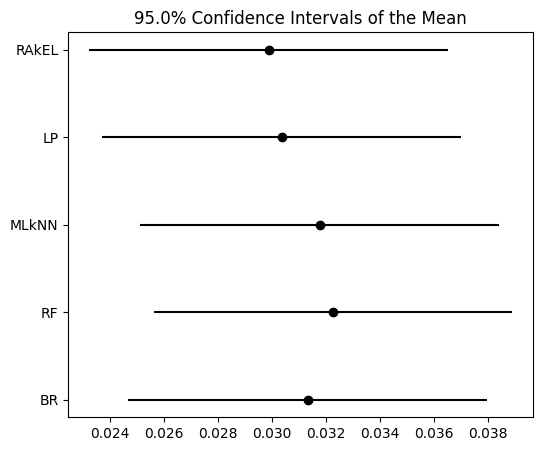


Wilcoxon: RAkEL vs LP
p-valor: 1.0

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.137255  0.137255  0.137255  0.137255  0.093137
1  0.141509  0.136792  0.136792  0.127358  0.136792
2  0.115385  0.144231  0.144231  0.153846  0.125000
3  0.153846  0.149038  0.139423  0.153846  0.168269
4  0.125000  0.139423  0.139423  0.139423  0.139423
       meanrank      mean       std ci_lower ci_upper effect_size   magnitude  \
BR         2.65  0.144562  0.028817      NaN      NaN         0.0  negligible   
RF         2.85  0.147964  0.027153      NaN      NaN   -0.121513  negligible   
LP         2.95  0.149859  0.023649      NaN      NaN    -0.20097       small   
RAkEL      3.05  0.149388  0.024550      NaN      NaN   -0.180293  negligible   
MLkNN      3.50  0.147390  0.031054      NaN      NaN   -0.094394  negligible   

      effect_size_above magnitude_above  
BR                  0.0      negligible  
RF            -0.121513   

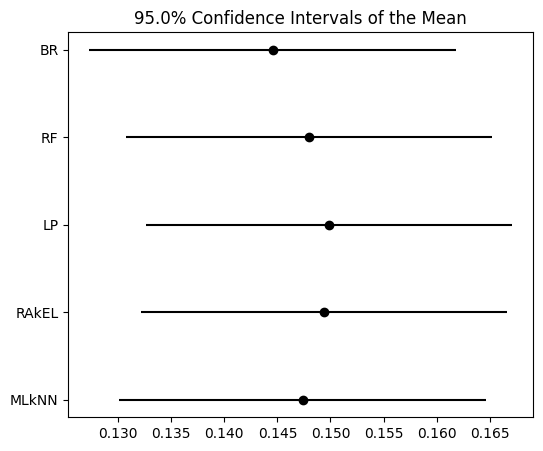


Wilcoxon: BR vs MLkNN
p-valor: 0.30078125


In [201]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_tuned_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_tuned_all[dataset], "hamming")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='ascending', verbose=False)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=True)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

##### F1-score


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.743961  0.712195  0.721951  0.753623  0.551724
1  0.663317  0.628272  0.676923  0.632124  0.526316
2  0.686567  0.663265  0.663366  0.682927  0.539535
3  0.688679  0.716981  0.723810  0.714286  0.507614
4  0.680000  0.659898  0.625000  0.682927  0.449761
Fail to reject null hypothesis that data is normal for column BR (p=0.429709>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.801147>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.103993>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.503447>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.197548>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.842467>=0.050000)
Rejecting null hypothesis that there is no

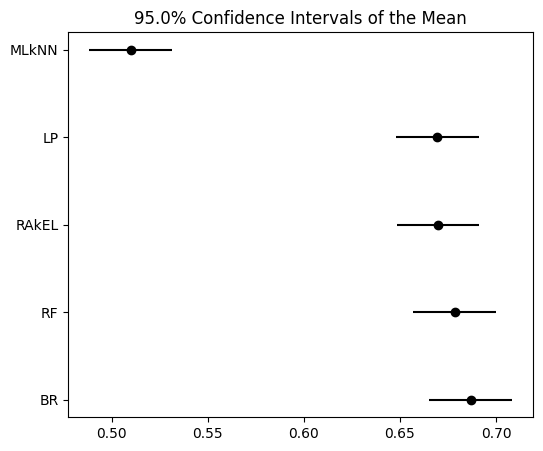


Wilcoxon: BR vs RF
p-valor: 0.16015625

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.869565  0.869565  0.869565  0.869565  0.851064
1  0.920000  0.938776  0.920000  0.938776  0.880000
2  0.880000  0.875000  0.893617  0.893617  0.936170
3  0.816327  0.791667  0.791667  0.765957  0.800000
4  0.708333  0.734694  0.708333  0.734694  0.745098
Fail to reject null hypothesis that data is normal for column BR (p=0.020534>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.731699>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.035997>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.447578>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.953848>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.974992>=0.050000)
Fai

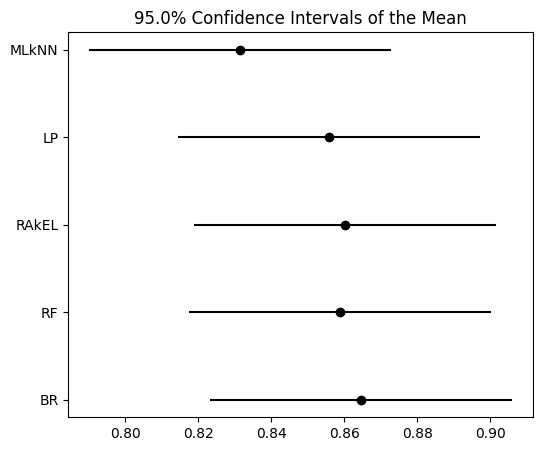


Wilcoxon: BR vs RAkEL
p-valor: 0.25

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.514286  0.387097  0.322581  0.444444  0.410256
1  0.400000  0.450000  0.444444  0.421053  0.418605
2  0.400000  0.333333  0.352941  0.228571  0.325581
3  0.411765  0.352941  0.294118  0.352941  0.585366
4  0.333333  0.285714  0.242424  0.187500  0.391304
Fail to reject null hypothesis that data is normal for column BR (p=0.447118>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.930380>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.934919>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.821524>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.551820>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.579782>=0.050000)
Re

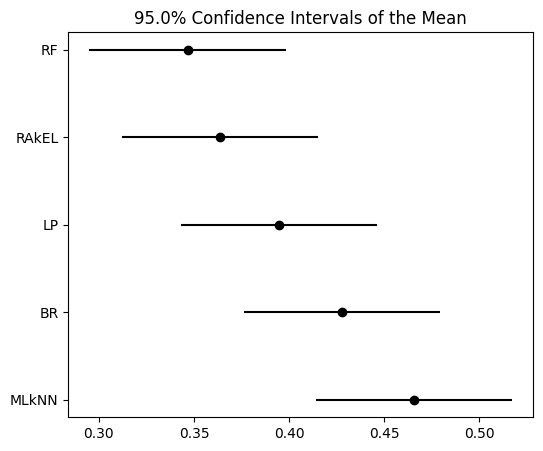


Wilcoxon: MLkNN vs BR
p-valor: 0.431640625

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.960000  0.960000  0.960000  0.960000  0.951456
1  0.971429  0.971429  0.971429  0.941176  0.912621
2  0.951456  0.932039  0.932039  0.932039  0.932039
3  0.942308  0.942308  0.942308  0.942308  0.941176
4  0.961538  0.961538  0.961538  0.970874  0.970874
Fail to reject null hypothesis that data is normal for column BR (p=0.580276>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.335865>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.590383>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.256424>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.322204>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.914493>=0.050

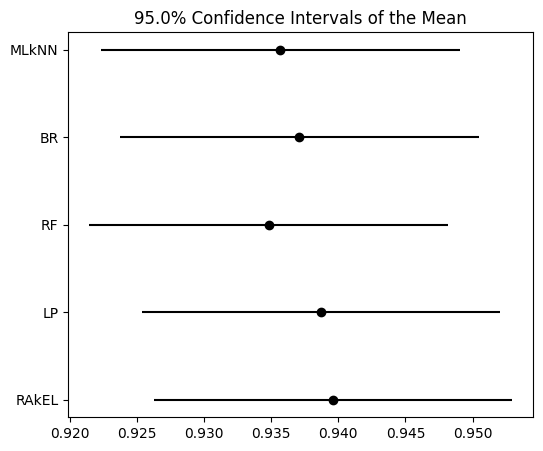


Wilcoxon: RAkEL vs LP
p-valor: 1.0

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.641026  0.650000  0.650000  0.658537  0.800000
1  0.651163  0.658824  0.658824  0.689655  0.694737
2  0.720930  0.642857  0.642857  0.619048  0.723404
3  0.600000  0.626506  0.650602  0.609756  0.623656
4  0.704545  0.666667  0.666667  0.650602  0.694737
Fail to reject null hypothesis that data is normal for column BR (p=0.338674>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.317043>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.133533>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.860006>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.937473>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.989662>=0.050000)

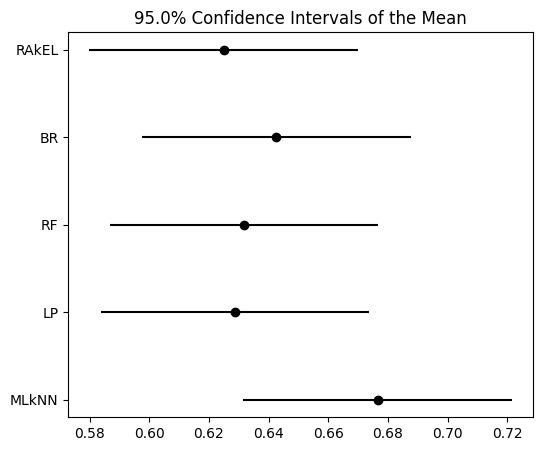


Wilcoxon: MLkNN vs BR
p-valor: 0.083984375


In [202]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_tuned_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_tuned_all[dataset], "f1_micro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.735422  0.689061  0.705273  0.731058  0.495545
1  0.643397  0.590733  0.651671  0.591360  0.430123
2  0.662186  0.639466  0.626362  0.649348  0.493747
3  0.632622  0.660177  0.672266  0.666968  0.445507
4  0.675035  0.641015  0.608256  0.674160  0.412139
Fail to reject null hypothesis that data is normal for column BR (p=0.021762>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.592858>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.591925>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.444750>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.442503>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.850676>=0.050000)
Rejecting null hypothesis that there is no

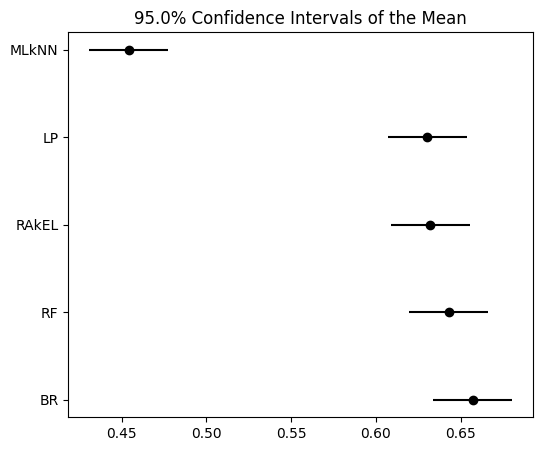


Wilcoxon: BR vs RF
p-valor: 0.064453125

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.691585  0.691585  0.691585  0.691585  0.736111
1  0.902116  0.910831  0.902116  0.925926  0.878307
2  0.732943  0.708325  0.716122  0.716122  0.712418
3  0.867857  0.853571  0.853571  0.837088  0.701389
4  0.627646  0.657407  0.627646  0.638367  0.629630
Fail to reject null hypothesis that data is normal for column BR (p=0.091604>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.272669>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.136601>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.364140>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.871461>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.999323>=0.050000)
Re

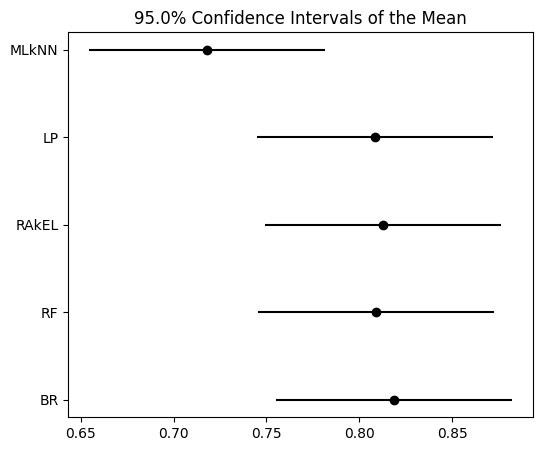


Wilcoxon: BR vs RAkEL
p-valor: 0.0625

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.214286  0.163170  0.137529  0.184127  0.238828
1  0.316162  0.331933  0.331439  0.328571  0.314286
2  0.151282  0.138095  0.148352  0.092308  0.130159
3  0.326923  0.301282  0.275641  0.297009  0.396825
4  0.294872  0.273504  0.252525  0.227273  0.325815
Fail to reject null hypothesis that data is normal for column BR (p=0.096256>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.052214>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.028044>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.622804>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.782816>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.423726>=0.050000)


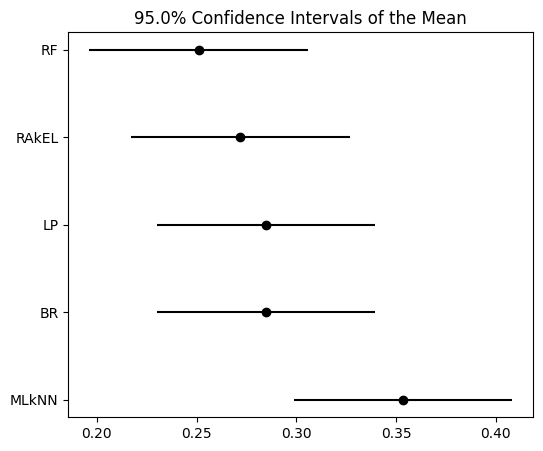


Wilcoxon: MLkNN vs BR
p-valor: 0.064453125

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.722024  0.722024  0.722024  0.722024  0.716880
1  0.976760  0.976760  0.976760  0.947748  0.914683
2  0.879091  0.860294  0.860294  0.860294  0.809816
3  0.877793  0.877793  0.877793  0.877793  0.880293
4  0.973011  0.973011  0.973011  0.978561  0.971591
Fail to reject null hypothesis that data is normal for column BR (p=0.011171>=0.010000)
Rejecting null hypothesis that data is normal for column LP (p=0.006332<0.010000)
Rejecting null hypothesis that data is normal for column RAkEL (p=0.007173<0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.012372>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.284166>=0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.974946>=0.050000)
Using Friedman tes

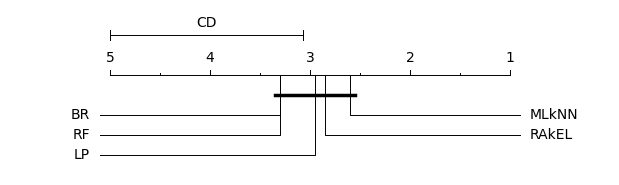


Wilcoxon: MLkNN vs RAkEL
p-valor: 0.322265625

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.438140  0.443011  0.443011  0.445929  0.603503
1  0.408929  0.408929  0.408929  0.467752  0.679352
2  0.529202  0.453620  0.453620  0.421474  0.550879
3  0.416038  0.426566  0.454046  0.418670  0.462148
4  0.507860  0.471232  0.471232  0.464672  0.661449
Fail to reject null hypothesis that data is normal for column BR (p=0.537072>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.771440>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.258329>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.351612>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.202149>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.295652

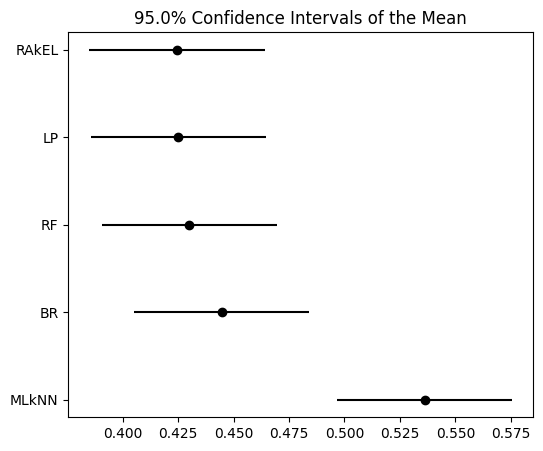


Wilcoxon: MLkNN vs BR
p-valor: 0.005859375


In [203]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_tuned_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_tuned_all[dataset], "f1_macro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

##### AUPRC


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.830075  0.813552  0.824120  0.810132  0.593266
1  0.755209  0.744682  0.766081  0.754680  0.616451
2  0.765655  0.750092  0.774374  0.761314  0.555718
3  0.766269  0.804508  0.786703  0.778213  0.548954
4  0.798918  0.776184  0.771706  0.758117  0.489578
Fail to reject null hypothesis that data is normal for column BR (p=0.809229>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.192950>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.435618>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.213385>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.411236>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.943484>=0.050000)
Rejecting null hypothesis that there is no

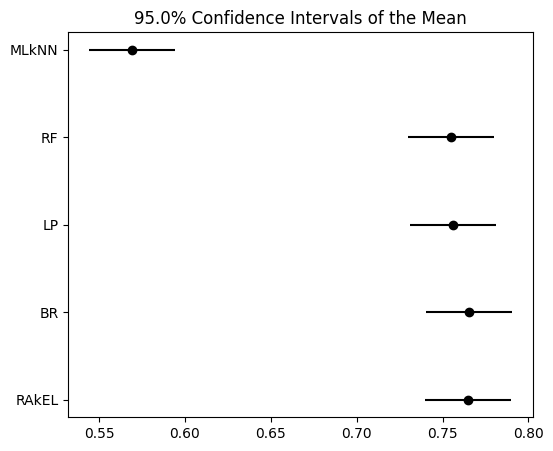


Wilcoxon: BR vs RAkEL
p-valor: 1.0

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.944491  0.941429  0.966472  0.949732  0.913647
1  0.927438  0.945849  0.949141  0.953604  0.897354
2  0.944928  0.954145  0.956383  0.960020  0.949649
3  0.880217  0.881793  0.880690  0.886977  0.937091
4  0.791919  0.803120  0.815783  0.798241  0.732663
Fail to reject null hypothesis that data is normal for column BR (p=0.050078>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.034585>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.042956>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.022788>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.352567>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.900305>=0.050000)
Rejecti

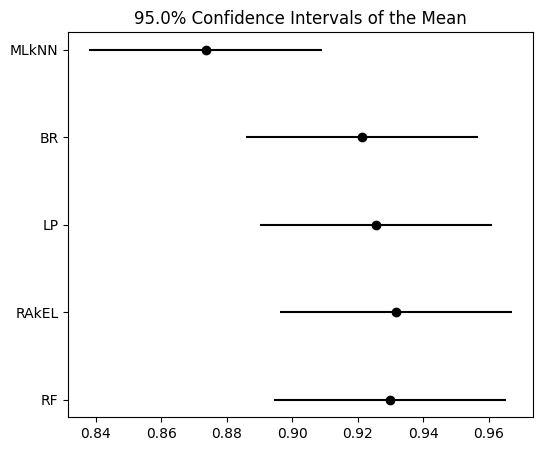


Wilcoxon: RAkEL vs RF
p-valor: 0.4921875

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.620333  0.588144  0.572218  0.571607  0.540644
1  0.540220  0.548292  0.510326  0.562937  0.432586
2  0.509781  0.544167  0.517207  0.521688  0.404546
3  0.606515  0.571542  0.570834  0.583550  0.601911
4  0.548742  0.527822  0.568648  0.561442  0.522131
Fail to reject null hypothesis that data is normal for column BR (p=0.553619>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.015884>=0.010000)
Rejecting null hypothesis that data is normal for column RAkEL (p=0.008908<0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.044621>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.891957>=0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.575495>=0.050000)
Using Friedman

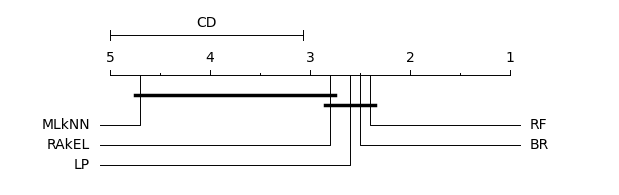


Wilcoxon: BR vs RF
p-valor: 0.845703125

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.976089  0.977804  0.977804  0.976616  0.983151
1  0.998595  0.998192  0.998932  0.997012  0.987244
2  0.989057  0.987631  0.987631  0.987588  0.973174
3  0.959138  0.967769  0.966913  0.967996  0.962118
4  0.997822  0.997486  0.997486  0.997848  0.989379
Fail to reject null hypothesis that data is normal for column BR (p=0.406195>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.487671>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.559597>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.635369>=0.010000)
Rejecting null hypothesis that data is normal for column MLkNN (p=0.009783<0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.688037>=0.050000)
Using Friedman 

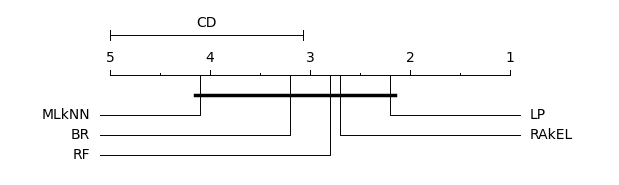


Wilcoxon: LP vs RAkEL
p-valor: 0.09375

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.877275  0.861837  0.861837  0.860832  0.879926
1  0.764158  0.807714  0.807714  0.765678  0.814395
2  0.840586  0.814948  0.814948  0.800737  0.790424
3  0.756848  0.773723  0.804837  0.755891  0.710636
4  0.779906  0.773408  0.773408  0.801773  0.741395
Fail to reject null hypothesis that data is normal for column BR (p=0.505875>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.519704>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.508437>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.490605>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.992731>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.999221>=0.050

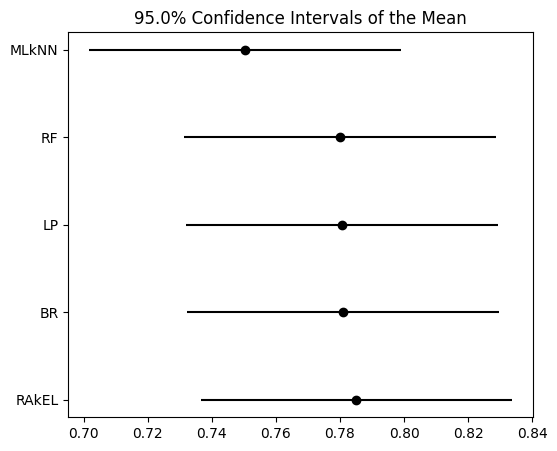


Wilcoxon: RAkEL vs BR
p-valor: 0.6953125


In [204]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_tuned_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_tuned_all[dataset], "auprc_micro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

##### AUC


===== DATASET: emotions =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.916468  0.910186  0.917987  0.914949  0.794829
1  0.870073  0.869614  0.879507  0.871008  0.791673
2  0.873356  0.865909  0.876077  0.868839  0.746224
3  0.895836  0.908255  0.903291  0.899073  0.763582
4  0.888920  0.878924  0.877450  0.871413  0.698171
Fail to reject null hypothesis that data is normal for column BR (p=0.736289>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.394251>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.653416>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.703923>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.783597>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.703200>=0.050000)
Rejecting null hypothesis that there is no

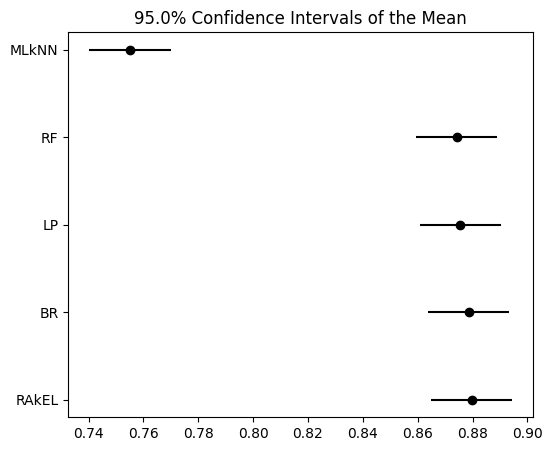


Wilcoxon: RAkEL vs BR
p-valor: 0.625

===== DATASET: VirusGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.984375  0.982422  0.990885  0.988281  0.965495
1  0.989583  0.990605  0.991422  0.992034  0.978145
2  0.983762  0.986931  0.987723  0.989109  0.964554
3  0.971287  0.975050  0.974653  0.973861  0.985347
4  0.935086  0.920350  0.911788  0.923536  0.914576
Rejecting null hypothesis that data is normal for column BR (p=0.001526<0.010000)
Rejecting null hypothesis that data is normal for column LP (p=0.000112<0.010000)
Rejecting null hypothesis that data is normal for column RAkEL (p=0.000039<0.010000)
Rejecting null hypothesis that data is normal for column RF (p=0.000294<0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.314003>=0.010000)
Using Levene's test for homoscedacity of non-normal data.
Fail to reject null hypothesis that all variances are equal (p=0.988450>=0.050000)
Using Friedman test as omnibus test
Reje

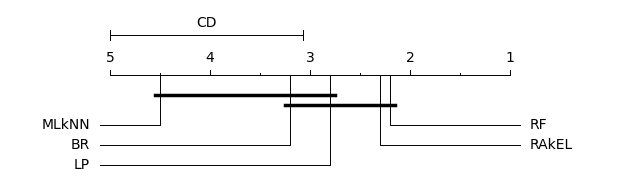


Wilcoxon: RF vs BR
p-valor: 0.193359375

===== DATASET: VirusPseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.849392  0.815972  0.838325  0.854167  0.797743
1  0.821895  0.841299  0.804534  0.844567  0.796773
2  0.807327  0.839406  0.822574  0.840792  0.812475
3  0.848713  0.840396  0.831485  0.848515  0.864950
4  0.823178  0.821585  0.837316  0.831740  0.791318
Fail to reject null hypothesis that data is normal for column BR (p=0.333332>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.266969>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.592977>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.872759>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.427112>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.569910>=0.050000

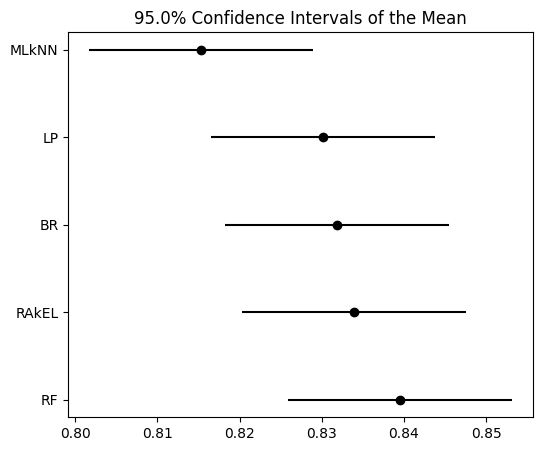


Wilcoxon: RF vs RAkEL
p-valor: 0.431640625

===== DATASET: GpositiveGO =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.981289  0.982955  0.982955  0.981866  0.990388
1  0.999525  0.999407  0.999644  0.999051  0.996143
2  0.995374  0.994400  0.994400  0.994522  0.981923
3  0.988104  0.989460  0.988536  0.988967  0.985639
4  0.999260  0.999260  0.999260  0.999322  0.995069
Fail to reject null hypothesis that data is normal for column BR (p=0.660586>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.472604>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.664422>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.504711>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.044482>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.167615>=0.050

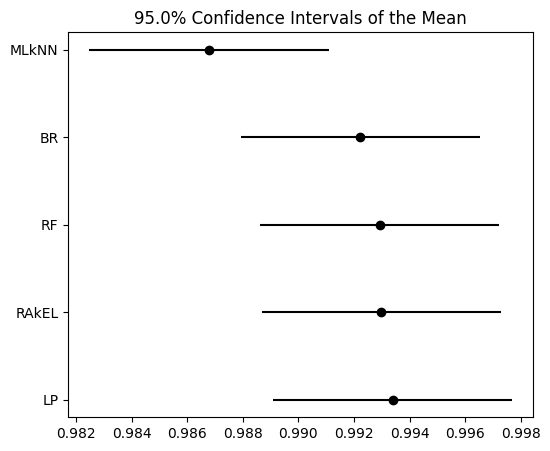


Wilcoxon: LP vs RAkEL
p-valor: 0.0625

===== DATASET: GpositivePseAAC =====

Tabela (folds):
         BR        LP     RAkEL        RF     MLkNN
0  0.940023  0.929707  0.929707  0.935538  0.946495
1  0.892251  0.910348  0.910348  0.891183  0.918239
2  0.907486  0.903956  0.903956  0.899087  0.910286
3  0.874260  0.888560  0.907853  0.888622  0.874014
4  0.885417  0.901997  0.901997  0.905387  0.887266
Fail to reject null hypothesis that data is normal for column BR (p=0.306809>=0.010000)
Fail to reject null hypothesis that data is normal for column LP (p=0.046478>=0.010000)
Fail to reject null hypothesis that data is normal for column RAkEL (p=0.013657>=0.010000)
Fail to reject null hypothesis that data is normal for column RF (p=0.219362>=0.010000)
Fail to reject null hypothesis that data is normal for column MLkNN (p=0.999577>=0.010000)
Using Bartlett's test for homoscedacity of normally distributed data
Fail to reject null hypothesis that all variances are equal (p=0.999390>=0.0500

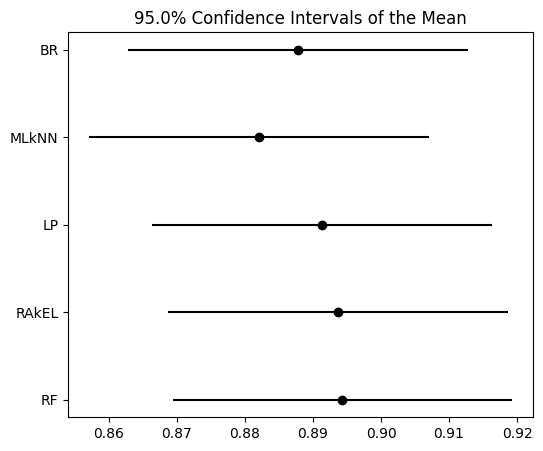


Wilcoxon: RF vs RAkEL
p-valor: 0.921875


In [205]:
def build_table_folds(results, metric):
    data = {}
    for model, folds in results.items():
        # transforma folds em lista
        if isinstance(folds, dict):
            folds = list(folds.values())
        data[model] = [fold[metric] for fold in folds]
    return pd.DataFrame(data)


for dataset in results_tuned_all:

    print(f"\n===== DATASET: {dataset} =====")

    # monta tabela por folds
    df = build_table_folds(results_tuned_all[dataset], "auc_micro")
    df = df.dropna()

    print("\nTabela (folds):")
    print(df.head())

    # teste de Friedman + Nemenyi
    result = autorank(df, alpha=0.05, order='descending', verbose=True)

    print("\nRanking médio:")
    print(result.rankdf)

    # gráfico
    plot_stats(result, allow_insignificant=True)
    plt.show()

    # Wilcoxon (2 melhores)
    means = df.mean().sort_values(ascending=False)
    m1, m2 = means.index[:2]

    stat, p = wilcoxon(df[m1], df[m2])

    print(f"\nWilcoxon: {m1} vs {m2}")
    print("p-valor:", p)

### Tabela de comparação: Default vs Tuned

In [206]:
def build_comparison_table(results_default_agg, results_tuned_agg, metric_name):
    rows = []

    for dataset in results_default_agg:

        # garante que dataset existe nos dois
        if dataset not in results_tuned_agg:
            continue

        row = {"dataset": dataset}

        for model in results_default_agg[dataset]:

            # garante que modelo existe nos dois
            if model not in results_tuned_agg[dataset]:
                continue

            mean_def = results_default_agg[dataset][model][metric_name][0]
            mean_tun = results_tuned_agg[dataset][model][metric_name][0]

            row[f"{model}_def"] = mean_def
            row[f"{model}_tun"] = mean_tun

            if metric_name == "hamming":
                diff = mean_def - mean_tun  # menor é melhor
            else:
                diff = mean_tun - mean_def  # maior é melhor

            row[f"{model}_diff"] = diff

        rows.append(row)

    df = pd.DataFrame(rows)
    df = df.set_index("dataset")

    # organiza colunas
    df = df.sort_index(axis=1)

    # arredondamento
    df = df.round(4)

    return df

In [207]:
metrics = [
    "hamming",
    "f1_micro",
    "f1_macro",
    "auprc_micro",
    "auc_micro"
]

for metric in metrics:
    print(f"\n===== {metric.upper()} =====")

    df = build_comparison_table(results_default_agg, results_tuned_agg, metric)

    print(df.to_string())


===== HAMMING =====
                 BR_def  BR_diff  BR_tun  LP_def  LP_diff  LP_tun  MLkNN_def  MLkNN_diff  MLkNN_tun  RAkEL_def  RAkEL_diff  RAkEL_tun  RF_def  RF_diff  RF_tun
dataset                                                                                                                                                       
emotions         0.1800      0.0  0.1800  0.1854   0.0008  0.1846     0.2582     -0.0076     0.2658     0.1802     -0.0053     0.1855  0.1840   0.0008  0.1832
VirusGO          0.0533     -0.0  0.0534  0.0550  -0.0008  0.0558     0.0790      0.0129     0.0662     0.0550      0.0008     0.0542  0.0549  -0.0001  0.0550
VirusPseAAC      0.1731      0.0  0.1731  0.1730   0.0008  0.1722     0.1911      0.0034     0.1877     0.1804      0.0048     0.1756  0.1796  -0.0024  0.1820
GpositiveGO      0.0313      0.0  0.0313  0.0299  -0.0005  0.0304     0.0303     -0.0015     0.0318     0.0323      0.0024     0.0299  0.0309  -0.0014  0.0323
GpositivePseAAC  0.1446  

Conclusão geral: A comparação entre os modelos com e sem otimização de parâmetros indica que, de modo geral, o tuning apresentou impacto limitado no desempenho. As diferenças observadas são, em sua maioria, pequenas e próximas de zero, sugerindo que os modelos já apresentavam desempenho estável na configuração padrão (default). Em alguns casos específicos, foram observadas melhorias ou quedas pontuais, mas sem um padrão consistente entre os modelos e datasets. A comparação entre os modelos com e sem otimização de parâmetros indica que, de modo geral, o tuning apresentou impacto limitado no desempenho. As diferenças observadas são, em sua maioria, pequenas e próximas de zero, sugerindo que os modelos já apresentavam desempenho estável na configuração padrão. Em alguns casos específicos, foram observadas melhorias ou quedas pontuais, mas sem um padrão consistente entre os modelos e datasets. Ademas, testes estatísticos indicaram que muitas dessas diferenças não são significativas, reforçando que o ganho com otimização foi modesto.